# LangGraph QuickStart

LangGraph는 상태 기반 멀티 액터 애플리케이션을 구축하기 위한 프레임워크입니다.

## 구현 기능

- 상태 관리 기반 챗봇
- 외부 도구 연동 (Tavily Search)
- 메모리 및 체크포인트
- Human-in-the-Loop
- 상태 커스터마이징
- 상태 이력 관리

## 환경 설정

LangGraph를 사용하기 위해 필요한 환경 변수와 로깅을 설정합니다. `.env` 파일에 API 키를 저장하고, LangSmith를 통해 실행 과정을 추적할 수 있습니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 추적을 위한 프로젝트 이름 설정
logging.langsmith("LangChain-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-V1-Tutorial


---

## 기본 챗봇 구축

메시지 기반 챗봇을 StateGraph로 구성합니다. StateGraph는 LangGraph의 핵심 구성 요소로, 노드와 엣지를 연결하여 상태 기반 워크플로우를 정의합니다.

> 📖 **참고 문서**: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api.md)

### 구성 요소

| 구성 요소 | 설명 |
|----------|------|
| StateGraph | 전체 워크플로우 흐름을 정의하는 그래프 |
| State | 그래프 실행 중 데이터를 저장하는 상태 객체 |
| Node | 실제 작업을 수행하는 함수 (예: LLM 호출) |
| Edge | 노드 간 실행 경로를 연결 |
| Compile/Invoke | 그래프를 실행 가능한 형태로 변환 및 호출 |

아래 코드는 State 타입을 정의하고 StateGraph 인스턴스를 생성합니다.

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# State 정의: 챗봇의 상태를 나타내는 타입
class State(TypedDict):
    """챗봇의 상태를 정의하는 타입

    messages: 대화 메시지 리스트
    - add_messages 함수를 통해 새 메시지가 추가됨 (덮어쓰기가 아닌 추가)
    """

    messages: Annotated[list, add_messages]


# StateGraph 생성
graph_builder = StateGraph(State)

print("StateGraph 생성 완료!")
print("State는 messages 키를 가지며, add_messages 리듀서를 사용합니다.")

StateGraph 생성 완료!
State는 messages 키를 가지며, add_messages 리듀서를 사용합니다.


### LLM 설정

LangGraph의 노드에서 사용할 언어 모델을 설정합니다. `init_chat_model` 함수를 사용하면 다양한 제공자(OpenAI, Anthropic 등)의 모델을 통일된 인터페이스로 사용할 수 있습니다.

아래 코드는 Anthropic의 Claude Sonnet 4.5 모델을 초기화합니다.

In [3]:
from langchain.chat_models import init_chat_model

# 모델 식별자 문자열을 사용한 간단한 방법
llm = init_chat_model("anthropic:claude-sonnet-4-5")

### 챗봇 노드 추가

노드는 그래프에서 실제 작업을 수행하는 함수입니다. 챗봇 노드는 현재 상태의 메시지를 받아 LLM에 전달하고, 응답을 새 메시지로 추가하여 반환합니다.

`add_node` 메서드의 첫 번째 인자는 노드의 고유 이름이고, 두 번째 인자는 호출될 함수입니다.

아래 코드는 챗봇 노드 함수를 정의하고 그래프에 추가합니다.

In [4]:
def chatbot(state: State):
    """챗봇 노드 함수

    현재 상태의 메시지를 받아 LLM에 전달하고,
    응답을 새 메시지로 추가하여 반환합니다.
    """
    # LLM을 호출하여 응답 생성
    response = llm.invoke(state["messages"])

    # 응답을 메시지 리스트에 추가하여 반환
    return {"messages": [response]}


# 그래프에 노드 추가
# 첫 번째 인자: 노드의 고유 이름
# 두 번째 인자: 노드가 사용될 때 호출될 함수
graph_builder.add_node("chatbot", chatbot)

### 엣지 설정

엣지는 노드 간의 실행 흐름을 정의합니다. `START`는 그래프 실행의 시작점이고, `END`는 종료점입니다. 모든 그래프는 반드시 시작점과 종료점을 가져야 합니다.

아래 코드는 실행 경로(START → chatbot → END)를 설정합니다.

In [5]:
# 진입점: 그래프 실행이 시작되는 지점
graph_builder.add_edge(START, "chatbot")

# 종료점: 그래프 실행이 끝나는 지점
graph_builder.add_edge("chatbot", END)

print("진입점과 종료점 설정 완료!")
print("실행 흐름: START → chatbot → END")

진입점과 종료점 설정 완료!
실행 흐름: START → chatbot → END


### 그래프 컴파일

StateGraph를 정의한 후에는 반드시 `compile()` 메서드를 호출하여 실행 가능한 형태로 변환해야 합니다. 컴파일 과정에서 노드 간 연결이 검증되고, 실행 순서가 결정됩니다.

아래 코드는 정의한 그래프를 컴파일하고 실행 가능한 객체를 반환합니다.

In [6]:
# 그래프 컴파일
graph = graph_builder.compile()

print("그래프 컴파일 완료!")

그래프 컴파일 완료!


### 그래프 시각화

컴파일된 그래프의 구조를 시각적으로 확인할 수 있습니다. `langchain_teddynote` 패키지의 `visualize_graph` 함수를 사용하면 노드와 엣지의 연결 상태를 한눈에 파악할 수 있습니다.

아래 코드는 컴파일된 그래프를 시각화합니다.

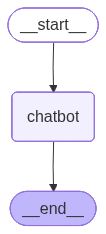

In [8]:
graph

In [7]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph)

그래프 시각화 실패 (추가 종속성 필요): Failed to reach https://mermaid.ink API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`
ASCII로 그래프 표시:
ASCII 표시도 실패: Install grandalf to draw graphs: `pip install grandalf`.


### 그래프 실행

`stream_graph` 함수를 사용하면 그래프 실행 결과를 스트리밍 방식으로 출력할 수 있습니다. `RunnableConfig`를 통해 재귀 깊이 제한(`recursion_limit`)과 스레드 식별자(`thread_id`)를 설정합니다.

아래 코드는 Config를 설정하고 사용자 입력을 준비합니다.

In [9]:
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage

# Config 설정(recursion_limit: 재귀 깊이 제한, thread_id: 스레드 아이디)
config = RunnableConfig(recursion_limit=20, thread_id="abc123")

In [10]:
inputs = {
    "messages": [HumanMessage(content="안녕하세요! LangGraph에 대해 알려주세요.")]
}

# 그래프 스트리밍
stream_graph(graph, inputs=inputs, config=config)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
# LangGraph 소개

안녕하세요! LangGraph에 대해 설명해드리겠습니다.

## LangGraph란?

**LangGraph**는 LangChain 팀이 개발한 라이브러리로, **상태를 가진 멀티 에이전트 애플리케이션**을 구축하기 위한 프레임워크입니다.

## 주요 특징

### 1. **그래프 기반 워크플로우**
- 노드(Node)와 엣지(Edge)로 구성된 그래프 구조
- 각 노드는 특정 작업을 수행하는 함수
- 에이전트의 실행 흐름을 명확하게 시각화

### 2. **상태 관리**
- 애플리케이션 전체에서 공유되는 상태(State) 관리
- 각 노드가 상태를 읽고 업데이트 가능
- 복잡한 대화 및 작업 컨텍스트 유지

### 3. **사이클 지원**
- 일반적인 체인과 달리 순환(cycle) 구조 지원
- 반복적인 작업이나 피드백 루프 구현 가능

### 4. **조건부 분기**
- 상태에 따라 다른 경로로 분기 가능
- 동적인 의사결정 로직 구현

## 주요 사용 사례

- 🤖 복잡한 AI 에이전트 시스템
- 💬 멀티턴 대화 시스템
- 🔄 반복적인 개선이 필요한 작업
- 🎯 조건부 실행 로직이 있는 워크플로우

더 구체적으로 알고 싶은 부분이 있으신가요?

---

## 도구(Tools) 추가

외부 검색 도구를 통합하여 실시간 정보를 조회할 수 있는 챗봇을 만듭니다. LangGraph는 LLM이 외부 도구를 호출하고 그 결과를 활용하는 워크플로우를 쉽게 구성할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Tool Integration](https://docs.langchain.com/oss/python/langgraph/tool-integration.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Tool Binding | LLM에 사용 가능한 도구를 연결하는 과정 |
| Tool Node | 실제 외부 API를 호출하는 노드 |
| Conditional Edges | LLM 응답에 따라 도구 사용 여부를 자동 분기 |

아래 코드는 간단한 덧셈 도구를 정의합니다.

In [11]:
# 공유
from langchain_core.tools import tool


@tool
def add(a: int, b: int):
    "두 숫자를 더합니다."
    return a + b

In [12]:
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition

# Tavily 검색 도구 설정
tool = TavilySearch(max_results=2)
tools = [tool, add]

# 도구 테스트
result = tool.invoke("LangGraph란 무엇인가요?")
print(f"검색 결과 수: {len(result['results'])}개")
print(f"첫 번째 결과 제목: {result['results'][0]['title']}")

검색 결과 수: 2개
첫 번째 결과 제목: 1-1. 랭그래프 LangGraph 소개 - 위키독스


### 도구 사용 그래프 구성

기본 챗봇 흐름에 도구 호출 경로를 추가합니다. LLM이 도구 호출을 요청하면 "tools" 노드로 이동하고, 도구 실행 후 다시 챗봇으로 돌아오는 순환 구조(chatbot ⇄ tools)를 구성합니다.

아래 코드는 LLM에 도구를 바인딩합니다.

In [13]:
llm_with_tools = llm.bind_tools(tools)

In [14]:
ret1 = llm_with_tools.invoke("LangGraph 가 뭐야?")
ret2 = llm_with_tools.invoke("LangGraph 가 뭐야? 검색해서 알려줘")

In [15]:
print(ret1.content)

[{'id': 'toolu_01EyNVxvxh1RuFDrL6u4EuWG', 'caller': {'type': 'direct'}, 'input': {'query': 'LangGraph', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type': 'tool_use'}]


In [19]:
add_result = llm_with_tools.invoke("3 + 4?")

In [16]:
from langchain_teddynote.messages import display_message_tree

display_message_tree(ret1)

    content:
        index [0]
            id: "toolu_01EyNVxvxh1RuFDrL6u4EuWG"
            caller: {"type": "direct"}
            input: {"query": "LangGraph", "search_depth": "advanced"}
            name: "tavily_search"
            type: "tool_use"
    additional_kwargs: {}
    response_metadata:
        id: "msg_016itqLKfaStGHMo2re2KtRP"
        container: None
        model: "claude-sonnet-4-5-20250929"
        stop_reason: "tool_use"
        stop_sequence: None
        usage:
            cache_creation: {"ephemeral_1h_input_tokens": 0, "ephemeral_5m_input_tokens": 0}
            cache_creation_input_tokens: 0
            cache_read_input_tokens: 0
            inference_geo: "not_available"
            input_tokens: 2286
            output_tokens: 75
            server_tool_use: None
            service_tier: "standard"
        model_name: "claude-sonnet-4-5-20250929"
        model_provider: "anthropic"
    type: "ai"
    name: None
    id: "lc_run--019d1373-4cc1-7e90-b7da-3537ca3

In [17]:
display_message_tree(ret2)

    content:
        index [0]
            id: "toolu_011DaRFNBSynJ247WptAsDcd"
            caller: {"type": "direct"}
            input: {"query": "LangGraph", "search_depth": "advanced"}
            name: "tavily_search"
            type: "tool_use"
    additional_kwargs: {}
    response_metadata:
        id: "msg_01651qj4TaiSBPsnoFU1unxH"
        container: None
        model: "claude-sonnet-4-5-20250929"
        stop_reason: "tool_use"
        stop_sequence: None
        usage:
            cache_creation: {"ephemeral_1h_input_tokens": 0, "ephemeral_5m_input_tokens": 0}
            cache_creation_input_tokens: 0
            cache_read_input_tokens: 0
            inference_geo: "not_available"
            input_tokens: 2296
            output_tokens: 75
            server_tool_use: None
            service_tier: "standard"
        model_name: "claude-sonnet-4-5-20250929"
        model_provider: "anthropic"
    type: "ai"
    name: None
    id: "lc_run--019d1373-547e-7150-b70e-ddbe64f

In [21]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# State 정의 (동일)
class State(TypedDict):
    messages: Annotated[list, add_messages]


# 새로운 그래프 빌더 생성
builder = StateGraph(State)

# LLM에 도구 바인딩 - LLM이 도구를 사용할 수 있도록 설정
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    """도구를 사용할 수 있는 챗봇 노드"""
    # 도구가 바인딩된 LLM 호출
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# 노드 추가
builder.add_node("chatbot", chatbot)

# ToolNode 추가 - 도구를 실행하는 노드
tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)

### 조건부 라우팅

`tools_condition`이 마지막 AI 메시지의 `tool_calls` 존재 여부를 확인해 경로를 분기합니다.

### tools_condition 동작

 `tool_calls` 존재 시 "tools"로, 없으면 "\_\_end\_\_"로 분기합니다.


def tools_condition(state) -> Literal["tools", "__end__"]:
    ai_message = state[-1] if isinstance(state, list) else state["messages"][-1]
    return "tools" if getattr(ai_message, "tool_calls", []) else "__end__"


In [24]:
# 조건부 엣지 추가
# tools_condition은 메시지에 tool_calls가 있으면 "tools"로,
# 없으면 END로 라우팅합니다
builder.add_conditional_edges(
    "chatbot",
    tools_condition,  # 사전 정의된 조건 함수 사용
)
# Literal["tools", "__end__"]

# 도구 실행 후 다시 챗봇으로 돌아가기
builder.add_edge("tools", "chatbot")

# 시작점 설정
builder.add_edge(START, "chatbot")

# 그래프 컴파일
graph_with_tools = builder.compile()

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Branch with name `tools_condition` already exists for node `chatbot`

### 그래프 시각화

도구가 연결된 그래프의 구조를 시각화합니다. chatbot 노드에서 조건에 따라 tools 노드로 분기하는 구조를 확인할 수 있습니다.

아래 코드는 도구가 연결된 그래프를 시각화합니다.

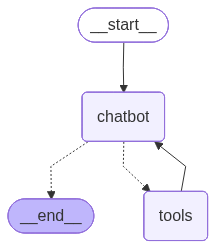

In [25]:
# 그래프 시각화
graph_with_tools

### 도구 사용 테스트

Tavily 검색 도구를 활용하여 최신 정보를 검색하는 테스트를 수행합니다. LLM이 질문에 답하기 위해 필요하다고 판단하면 자동으로 검색 도구를 호출합니다.

아래 코드는 2025년 LangGraph 사용 사례에 대한 검색을 수행합니다.

In [26]:
from langchain_teddynote.messages import stream_graph

stream_graph(
    graph_with_tools,
    inputs={
        "messages": [HumanMessage(content="2025년 LangGraph 사용 사례 알려주세요.")]
    },
    config=config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "LangGraph 사용 사례 2025", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://velog.io/@judy_choi/LangCon2025-%ED%9B%84%EA%B8%B0", "title": "LangCon2025 후기 - velog", "content": "GitHub : langcon-2025-handson\n\n`LangGraph`\n\nLangChain 일타강사 테디님의 강의!! 🤩  \n역시 일타강사님이신 데에는 다 이유가 있었다... ✨\n\n첫 핸즈온 세션에서 천천히 쉽게 Agent 에 대한 개념을 잡았다면  \n이번 세션에서는 코드를 이용해 Agent 를 구현하는 방법과  \n챗봇 개발에 꼭 고려해야 할 점 (멀티턴 대화를 위한 단기 메모리 Long-term 메모리, 라우팅 등등) 까지 배울 수 있었다.  \n내가 이 강의를 일찍 들었다면 더 좋은 챗봇을 만들 수 있었을텐데! 😂\n\n나는 학부 때부터 그래프를 싫어해서 LangGraph 는 막연히 하기 싫었는데 😞  \n테디쌤의 설명을 들으며 코드를 보니 세상에 이렇게 쉬울 수가!  \n게다가 LangSmith 로 Agent 모니터링까지 할 수 있어서 개발할 때 완전 유용해 보였다.\n\nLangGraph 코드를 보며 전통적인 챗봇과 약간 다르다고 느낀 것이  \n기존 챗봇에서는 사용자의 intent 를 파악하는 것이 매우 중요했다.  \n사용자의 intent 를 알아야 정확하게 분기하여 기능을 수행할 수 있었으니까.  \n생각해보니 LangGraph 핸즈온 코드에는 사용자의 intent 를 파악하는 기능이 없는데  

---

## 메모리 추가

세션 간 사용자 정보를 유지하는 영구 상태 관리를 추가합니다. 메모리 기능을 통해 챗봇이 이전 대화 내용을 기억하고, 사용자별로 개인화된 응답을 제공할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Persistence](https://docs.langchain.com/oss/python/langgraph/persistence.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Checkpointer | 그래프 실행 중 상태를 저장하고 복원하는 컴포넌트 |
| Thread ID | 동일 세션을 식별하는 고유 식별자 |
| User ID | 사용자별 장기 기억을 관리하는 식별자 |
| Persistent State | 누적된 대화 이력 기반의 컨텍스트 |

아래 코드는 메모리 추출을 위한 Pydantic 모델과 추출기를 정의합니다.

In [27]:
from typing import List, Optional
from datetime import datetime
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import PydanticOutputParser
import os


# Pydantic 모델 정의
class MemoryItem(BaseModel):
    """개별 메모리 아이템"""

    key: str = Field(description="메모리 키 (예: user_name, preference, fact)")
    value: str = Field(description="메모리 값")
    category: str = Field(
        description="카테고리 (personal_info, preference, interest, relationship, fact, etc.)"
    )
    importance: int = Field(description="중요도 (1-5, 5가 가장 중요)", ge=1, le=5)
    confidence: float = Field(description="추출 신뢰도 (0.0-1.0)", ge=0.0, le=1.0)


class ExtractedMemories(BaseModel):
    """추출된 메모리 컬렉션"""

    memories: List[MemoryItem] = Field(description="추출된 메모리 아이템 리스트")
    summary: str = Field(description="대화 내용 요약")
    timestamp: str = Field(
        default_factory=lambda: datetime.now().isoformat(), description="추출 시간"
    )


# 기본 시스템 프롬프트
DEFAULT_SYSTEM_PROMPT = """You are an expert memory extraction assistant. Your task is to extract important information from user conversations and convert them into structured key-value pairs for long-term memory storage.

Extract ALL relevant information from the conversation, including:
- Personal information (name, age, location, occupation, etc.)
- Preferences and interests
- Relationships and social connections
- Important facts or events mentioned
- Opinions and beliefs
- Goals and aspirations
- Any other notable information

For each piece of information:
1. Create a concise, searchable key
2. Store the complete value
3. Categorize appropriately
4. Assess importance (1-5 scale)
5. Evaluate extraction confidence (0.0-1.0)"""


def create_memory_extractor(
    model_name: Optional[str] = "anthropic:claude-sonnet-4-5",
    system_prompt: Optional[str] = None,
) -> any:
    """메모리 추출기를 생성합니다.

    Args:
        model: 사용할 언어 모델. None일 경우 기본 ChatOpenAI 모델 사용
        system_prompt: 시스템 프롬프트. None일 경우 기본 프롬프트 사용

    Returns:
        메모리 추출 체인
    """
    # Output Parser 생성
    memory_parser = PydanticOutputParser(pydantic_object=ExtractedMemories)

    # 시스템 프롬프트 설정
    if system_prompt is None:
        system_prompt = DEFAULT_SYSTEM_PROMPT

    # 전체 프롬프트 템플릿 구성
    template = f"""{system_prompt}

User Input: {{input}}

{{format_instructions}}

Remember to:
- Extract multiple memory items if the conversation contains various pieces of information
- Use clear, consistent key naming conventions
- Preserve context in values when necessary
- Be comprehensive but avoid redundancy
"""

    # 프롬프트 생성
    prompt = ChatPromptTemplate.from_template(
        template,
        partial_variables={
            "format_instructions": memory_parser.get_format_instructions()
        },
    )

    # 모델 설정
    model = init_chat_model(model_name)

    # 메모리 추출 체인 생성
    memory_extractor = prompt | model | memory_parser

    return memory_extractor

In [28]:
from typing import Any
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.store.base import BaseStore
from langchain_openai import ChatOpenAI

from langchain_teddynote.memory import create_memory_extractor
import uuid

model = init_chat_model("anthropic:claude-sonnet-4-5")
memory_extractor = create_memory_extractor(model="anthropic:claude-sonnet-4-5")


def call_model(
    state: MessagesState,
    config: RunnableConfig,
    *,
    store: BaseStore,
) -> dict[str, Any]:
    """LLM 모델을 호출하고 사용자 메모리를 관리합니다.

    Args:
        state (MessagesState): 메시지를 포함하는 현재 상태
        config (RunnableConfig): 실행 가능 구성
        store (BaseStore): 메모리 저장소
    """
    # 마지막 메시지에서 user_id 추출
    user_id = config["configurable"]["user_id"]
    namespace = ("memories", user_id)

    print(namespace)

    # 유저의 메모리 검색
    memories = store.search(namespace, query=str(state["messages"][-1].content))
    info = "\n".join([f"{memory.key}: {memory.value}" for memory in memories])
    system_msg = f"You are a helpful assistant talking to the user. User info: {info}"

    # 사용자가 기억 요청 시 메모리 저장
    last_message = state["messages"][-1]
    if "remember" in last_message.content.lower():
        result = memory_extractor.invoke({"input": str(state["messages"][-1].content)})
        for memory in result.memories:
            print(memory)
            print("-" * 100)
            store.put(namespace, str(uuid.uuid4()), {memory.key: memory.value})

    # LLM 호출
    response = model.invoke(
        [{"role": "system", "content": system_msg}] + state["messages"]
    )
    return {"messages": response}

In [29]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

# 그래프 빌드
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

# 메모리 체크포인터 생성
# 실제 프로덕션에서는 PostgresSaver 사용 권장
memory_saver = InMemorySaver()
memory_store = InMemoryStore()

# 그래프 컴파일
graph_with_memory = builder.compile(
    checkpointer=memory_saver,
    store=memory_store,
)

In [30]:
from langchain_teddynote.messages import stream_graph


def run_graph(
    msg,
    thread_id="default",
    user_id="default",
):
    config = {
        "configurable": {
            "thread_id": thread_id + user_id,
            "user_id": user_id,
        }
    }
    print(f"\n[유저] {msg}")
    stream_graph(
        graph_with_memory,
        inputs={"messages": [{"role": "user", "content": msg}]},
        config=config,
    )
    print()

In [31]:
# 메시지, thread_id, user_id 전달
run_graph("안녕? 내 이름은 테디야", "1", "someone")


[유저] 안녕? 내 이름은 테디야
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요, 테디님! 만나서 반가워요. 😊

오늘 무엇을 도와드릴까요? 궁금한 것이나 이야기하고 싶은 것이 있다면 편하게 말씀해 주세요!


In [32]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "1", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
당신의 이름은 테디라고 하셨어요! 😊


In [33]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "2", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
죄송하지만, 저는 당신의 이름을 알지 못합니다. 이전 대화에서 이름을 말씀하신 적이 없고, 저는 대화 기록에 접근할 수 없습니다.

이름을 알려주시면 대화하는 동안 그렇게 부르겠습니다. 😊


### 장기 기억 저장

메시지에 `remember` 키워드 포함 시 장기 저장소에 정보를 기록합니다.

In [34]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 테디야 remember", "2", "someone")


[유저] 내 이름이 테디야 remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "user_name",
      "value": "테디",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 자신의 이름이 '테디'라고 밝혔음.",
  "timestamp": "2024-06-13T00:00:00Z"
}key='user_name' value='테디' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
알겠습니다, 테디님! 😊 

기억할게요. 앞으로 테디님이라고 부르겠습니다. 

무엇을 도와드릴까요?


### Thread 간 지속성

User ID 기반 장기 기억은 Thread가 달라도 유지됩니다.

In [35]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고 했더라?", "1004", "someone")


[유저] 내 이름이 뭐라고 했더라?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
당신의 이름은 **테디**라고 하셨어요! 😊


In [36]:
# 메시지, thread_id, user_id 전달
run_graph(
    "내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember", "4", "someone"
)


[유저] 내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "occupation",
      "value": "AI Engineer",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    },
    {
      "key": "hobby",
      "value": "Netflix 보기",
      "category": "preference",
      "importance": 4,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 AI Engineer로 일하며, 취미는 Netflix 시청임을 밝혔다.",
  "timestamp": "2024-06-21T00:00:00Z"
}key='occupation' value='AI Engineer' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
key='hobby' value='Netflix 보기' category='preference' importance=4 confidence=1.0
----------------------------------------------------------------------------------------------------
네, 알겠습니다! 기억할게요. 😊

**7dac7ec7-b89b-4506-95c7-a8e5768d898

In [37]:
# 다른 스레드에서 실행
run_graph("내 이름, 직업, 취미 알려줘", "100", "someone")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! 제가 알고 있는 정보를 알려드리겠습니다:

- **이름**: 테디
- **직업**: AI Engineer (AI 엔지니어)
- **취미**: Netflix 보기

AI 엔지니어로 일하시면서 Netflix로 여가를 즐기시는군요! 😊


In [38]:
# 다른 user_id 로 실행한 경우
run_graph("내 이름, 직업, 취미 알려줘", "100", "other")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'other')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
죄송하지만, 저는 당신의 개인 정보(이름, 직업, 취미)를 알지 못합니다. 

우리의 대화는 지금 막 시작되었고, 당신에 대한 어떤 사전 정보도 제공받지 못했습니다. 

만약 당신에 대해 알려주신다면, 대화 중에 그 정보를 기억하고 더 개인화된 도움을 드릴 수 있습니다. 자기소개를 해주시겠어요?


### State 확인

저장된 상태를 조회하여 메시지 이력과 체크포인트 정보를 확인합니다. `get_state` 메서드를 통해 현재 상태의 스냅샷을 가져올 수 있습니다.

아래 코드는 특정 Config에 대한 현재 상태 정보를 조회합니다.

In [39]:
# 임의의 Config 설정
config = {
    "configurable": {
        "thread_id": "100" + "someone",
        "user_id": "someone",
    }
}

# 현재 상태 가져오기
snapshot = graph_with_memory.get_state(config)

print("현재 상태 정보:")
print(f"- 메시지 수: {len(snapshot.values['messages'])}개")
print(f"- 체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")

# 최근 메시지 몇 개 표시
print("\n[최근 메시지]")
for msg in snapshot.values["messages"]:
    role = msg.type if hasattr(msg, "type") else "unknown"
    content = msg.content if hasattr(msg, "content") else str(msg)
    print(f"  [{role}]: {content}")

현재 상태 정보:
- 메시지 수: 2개
- 체크포인트 ID: 1f1259c1-15f3-64a0-8001-05ab099f1802

[최근 메시지]
  [human]: 내 이름, 직업, 취미 알려줘
  [ai]: 안녕하세요! 제가 알고 있는 정보를 알려드리겠습니다:

- **이름**: 테디
- **직업**: AI Engineer (AI 엔지니어)
- **취미**: Netflix 보기

AI 엔지니어로 일하시면서 Netflix로 여가를 즐기시는군요! 😊


---

## Human-in-the-Loop

고위험 작업에 대해 인간 승인을 요청하는 흐름을 도입합니다. 중요한 결정이나 민감한 작업 수행 전에 사람의 확인을 받을 수 있어 AI 시스템의 안전성을 높입니다.

> 📖 **참고 문서**: [LangGraph Interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| interrupt | 그래프 실행을 일시정지하고 외부 입력을 대기 |
| Command | 승인/거부 후 재개 명령을 전달하는 객체 |
| Human Approval | 사람이 검토하고 승인하는 워크플로우 |

아래 코드는 사람의 도움을 요청하는 도구를 정의합니다.

In [40]:
from langchain_core.tools import tool
from langgraph.types import Command, interrupt


@tool
def human_assistance(query: str) -> str:
    """Request assistance from an expert(human)."""
    # interrupt를 호출하여 실행 일시 중지
    # 사람의 응답을 기다림
    human_response = interrupt({"query": query})

    # 사람의 응답 반환
    return human_response["data"]

### HITL 그래프 구성

`human_assistance` 도구를 사용하는 그래프를 구성합니다. 이 도구가 호출되면 `interrupt`로 실행이 중단되고, 사람의 응답을 기다립니다. 응답이 입력되면 해당 내용을 반환하여 대화를 계속합니다.

아래 코드는 Human-in-the-Loop 기능이 포함된 그래프를 구성합니다.

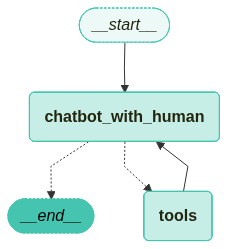

In [41]:
# 도구 리스트 업데이트
tools_with_human = [human_assistance]

# 새로운 그래프 구성
graph_builder_hitl = StateGraph(State)

# LLM에 도구 바인딩
llm_with_human_tools = llm.bind_tools(tools_with_human)


def chatbot_with_human(state: State):
    """Human Interuption 요청할 수 있는 챗봇"""
    message = llm_with_human_tools.invoke(state["messages"])

    # interrupt 중 병렬 도구 호출 방지
    # (재개 시 도구 호출이 반복되는 것을 방지)
    if hasattr(message, "tool_calls"):
        assert (
            len(message.tool_calls) <= 1
        ), "병렬 도구 호출은 interrupt와 함께 사용할 수 없습니다"

    return {"messages": [message]}


# 노드 추가
graph_builder_hitl.add_node("chatbot_with_human", chatbot_with_human)

# ToolNode 추가
tool_node_hitl = ToolNode(tools=tools_with_human)
graph_builder_hitl.add_node("tools", tool_node_hitl)

# 엣지 추가
graph_builder_hitl.add_conditional_edges("chatbot_with_human", tools_condition)
graph_builder_hitl.add_edge("tools", "chatbot_with_human")
graph_builder_hitl.add_edge(START, "chatbot_with_human")

# 메모리와 함께 컴파일
memory_hitl = InMemorySaver()
graph_hitl = graph_builder_hitl.compile(checkpointer=memory_hitl)

# 그래프 시각화
visualize_graph(graph_hitl)

### HITL 테스트

사람에게 조언을 요청하는 질문으로 interrupt와 재개 흐름을 검증합니다. 그래프가 중단되면 `get_state`로 현재 상태를 확인하고, `Command(resume=...)`로 재개할 수 있습니다.

아래 코드는 인간 지원을 요청하는 메시지로 그래프를 실행합니다.

In [42]:
from langchain_teddynote.messages import random_uuid

# 인간 지원을 요청하는 메시지
user_input = "LangGraph 가 뭐야? 사람한테 듣고 싶어."
config_hitl = {"configurable": {"thread_id": random_uuid()}}

print(f"User: {user_input}\n")

stream_graph(
    graph_hitl,
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=config_hitl,
)

User: LangGraph 가 뭐야? 사람한테 듣고 싶어.


🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [43]:
# 상태 확인 - 어느 노드에서 중단되었는지 확인
snapshot = graph_hitl.get_state(config_hitl)
print(f"\n현재 상태:")
print(f"  다음 실행할 노드: {snapshot.next}")
print(f"  체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")


현재 상태:
  다음 실행할 노드: ('tools',)
  체크포인트 ID: 1f1259c9-b25f-6199-8001-a7e55fc2db7a


In [44]:
# 인간의 응답으로 실행 재개
human_response = """## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)
"""

# Command 객체로 재개
human_command = Command(resume={"data": human_response})

print(f"\n사람의 응답: {human_response}\n")

# 재개
stream_graph(graph_hitl, inputs=human_command, config=config_hitl)


사람의 응답: ## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)



🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)

🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
전문가에게 문의한 결과, LangGraph에 대해 더 자세히 알아보실 수 있는 리소스를 안내받았습니다:

**LangGraph 학습 자료:**
- 📺 YouTube 테디노트 채널: https://www.youtube.com/c/teddynote
- 📚 패스트캠퍼스 고급 개발자 강의 (RAG 비법노트): https://fastcampus.co.kr/data_online_teddy

간단히 설명드리자면, **LangGraph**는 LangChain에서 개발한 프레임워크로, 복잡한 AI 에이전트와 워크플로우를 그래프 구조로 구축할 수 있게 해주는 도구입니다. 특히 상태를 관리하고 순환적인 로직을 구현할 수 있어서 더 정교한 AI 애플리케이션을 만들 수 있습니다.

위의 리소스들을 통해 전문가의 상세한 설명을 직접 들어보시는 것을 추천드립니다!

---

## 상태 커스터마이징

메시지 외에 업무 데이터를 다루는 커스텀 상태와 도구 기반 상태 업데이트를 도입합니다. `Command` 객체를 사용하면 도구 실행 결과로 상태를 직접 갱신할 수 있습니다.

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Custom State Fields | messages 외에 추가 필드를 정의 |
| State Updates from Tools | 도구 결과로 상태를 직접 갱신 |
| Command(update=...) | 상태 업데이트를 지정하는 명령 객체 |

아래 코드는 `human_feedback` 필드가 추가된 커스텀 상태를 정의합니다.

In [45]:
from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId


# 확장된 State 정의
class CustomState(TypedDict):
    """커스텀 필드가 추가된 상태"""

    messages: Annotated[list, add_messages]
    human_feedback: str  # 사람의 피드백

### 상태 업데이트 도구

도구 실행 결과를 `Command(update=...)`로 상태에 반영합니다. 이 패턴을 사용하면 도구가 단순히 문자열을 반환하는 것이 아니라, 상태의 특정 필드를 직접 수정할 수 있습니다.

아래 코드는 인간 검토를 요청하고 피드백에 따라 상태를 업데이트하는 도구를 정의합니다.

In [46]:
@tool
def human_review(
    human_feedback, tool_call_id: Annotated[str, InjectedToolCallId]
) -> str:
    """Request human review for information."""
    # 인간에게 검토 요청
    human_response = interrupt(
        {"question": "이 정보가 맞나요?", "human_feedback": human_feedback}
    )

    feedback = human_response.get("human_feedback", "")

    if feedback.strip() == "":
        # 사용자가 AI 의 답변에 동의하는 경우
        return Command(
            update={
                "messages": [ToolMessage(human_response, tool_call_id=tool_call_id)]
            }
        )
    else:
        # 사용자가 AI 의 답변에 동의하지 않는 경우
        corrected_information = f"# 사용자에 의해 수정된 피드백: {feedback}"
        return Command(
            update={
                "messages": [
                    ToolMessage(corrected_information, tool_call_id=tool_call_id)
                ]
            }
        )

### 커스텀 상태 그래프

`CustomState`를 사용하여 그래프를 구성합니다. 기본 `State` 대신 커스텀 상태를 사용하면 애플리케이션에 필요한 추가 데이터를 관리할 수 있습니다.

아래 코드는 커스텀 상태와 `human_review` 도구를 사용하는 그래프를 구성합니다.

In [47]:
# 도구 리스트
tools_custom = [human_review]

# 새로운 그래프 구성
custom_graph_builder = StateGraph(CustomState)  # CustomState 사용

# LLM에 도구 바인딩
llm_with_custom_tools = llm.bind_tools(tools_custom)


def chatbot_custom(state: CustomState):
    """커스텀 상태를 사용하는 챗봇"""
    message = llm_with_custom_tools.invoke(state["messages"])

    if hasattr(message, "tool_calls"):
        assert len(message.tool_calls) <= 1

    return {"messages": [message]}


# 노드와 엣지 추가
custom_graph_builder.add_node("chatbot", chatbot_custom)
tool_node_custom = ToolNode(tools=tools_custom)
custom_graph_builder.add_node("tools", tool_node_custom)

custom_graph_builder.add_conditional_edges("chatbot", tools_condition)
custom_graph_builder.add_edge("tools", "chatbot")
custom_graph_builder.add_edge(START, "chatbot")

# 컴파일
memory_custom = InMemorySaver()
custom_graph = custom_graph_builder.compile(checkpointer=memory_custom)

### 그래프 시각화

커스텀 상태 그래프의 구조를 시각화합니다. 기본 도구 그래프와 동일한 구조이지만, 내부적으로 `CustomState`를 사용합니다.

아래 코드는 커스텀 상태 그래프를 시각화합니다.

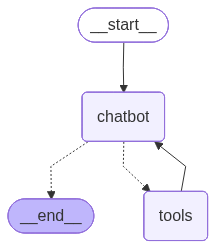

In [48]:
# 그래프 시각화
custom_graph

### 커스텀 상태 테스트

`human_review` 도구 호출 시 interrupt로 중단되고, 재개 시 사용자 피드백에 따라 상태가 갱신되는지 확인합니다. 사용자가 빈 피드백을 제공하면 AI의 답변에 동의하는 것으로 처리됩니다.

아래 코드는 인간 검토가 필요한 질문으로 그래프를 실행합니다.

In [49]:
# LangGraph의 출시일을 조사하고 검토 요청
user_input = (
    "2024년 노벨 문학상 수상자가 누구인지 조사해주세요. "
    "답을 찾으면 `human_review` 도구를 사용해서 검토를 요청하세요."
)

custom_config = RunnableConfig(configurable={"thread_id": random_uuid()})

print(f"User: {user_input}\n")

# 실행 (interrupt에서 중단될 것임)
stream_graph(
    custom_graph,
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=custom_config,
)

User: 2024년 노벨 문학상 수상자가 누구인지 조사해주세요. 답을 찾으면 `human_review` 도구를 사용해서 검토를 요청하세요.


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [50]:
from langchain_teddynote.messages import display_message_tree

# 최신 메시지 가져오기
last_message = custom_graph.get_state(custom_config).values["messages"][-1]

# 최신 메시지 tree 구조로 표시
display_message_tree(last_message)

    content:
        index [0]
            id: "toolu_01H9SuBhzwam61qkJR3ZhsXH"
            caller: {"type": "direct"}
            input: {}
            name: "human_review"
            type: "tool_use"
            index: 0
            partial_json: "{"human_feedback": "2024년 노벨 문학상 수상자는 한강(Han Kang)입니다. \n\n한강은 한국의 소설가로, 1970년 광주에서 태어났으며, \"채식주의자\", \"소년이 온다\", \"흰\" 등의 작품으로 유명합니다. 그녀는 \"인간의 취약성에 대한 강렬한 시적 산문과 역사적 트라우마에 직면하는 통찰\"을 인정받아 2024년 노벨 문학상을 수상했습니다.\n\n한강은 아시아 여성 최초로 노벨 문학상을 수상한 작가이며, 한국인으로서는 최초의 노벨 문학상 수상자입니다.\n\n이 정보가 정확한지 검토 부탁드립니다."}"
    additional_kwargs: {}
    response_metadata: {"model_name": "claude-sonnet-4-5-20250929", "model_provider": "anthropic", "stop_reason": "tool_use", "stop_sequence": None}
    type: "ai"
    name: None
    id: "lc_run--019d1388-8cb3-7323-8ec0-3657d27667f2"
    tool_calls:
        index [0]
            name: "human_review"
            args: {"human_feedback": "2024년 노벨 문학상 수상자는 한강(Han Kang)입니다. 

한강은 한국의 소설가로, 1970년 광주에서 태어났으며, "채식주의자", "소년

In [51]:
# AI 가 작성한 내용
print(last_message.tool_calls[0]["args"]["human_feedback"])

2024년 노벨 문학상 수상자는 한강(Han Kang)입니다. 

한강은 한국의 소설가로, 1970년 광주에서 태어났으며, "채식주의자", "소년이 온다", "흰" 등의 작품으로 유명합니다. 그녀는 "인간의 취약성에 대한 강렬한 시적 산문과 역사적 트라우마에 직면하는 통찰"을 인정받아 2024년 노벨 문학상을 수상했습니다.

한강은 아시아 여성 최초로 노벨 문학상을 수상한 작가이며, 한국인으로서는 최초의 노벨 문학상 수상자입니다.

이 정보가 정확한지 검토 부탁드립니다.


In [52]:
# 인간의 검토 응답으로 재개
human_command = Command(
    resume={"human_feedback": "2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다."}
)

stream_graph(custom_graph, inputs=human_command, config=custom_config)


🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
# 사용자에 의해 수정된 피드백: 2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다.
🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네, 확인되었습니다! 

**2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다.**

한강은 한국 문학의 위상을 세계적으로 높인 작가로, 인간의 고통과 트라우마, 그리고 회복에 대한 깊이 있는 성찰을 담은 작품들로 평가받고 있습니다.

---

## 상태 이력 관리

체크포인트 기반으로 상태를 저장/복원하여 롤백/재실행합니다. 이 기능을 통해 특정 시점으로 돌아가 다른 경로로 실행하거나, 실행 이력을 분석할 수 있습니다.

### 핵심 개념

| 개념 | 설명 |
|------|------|
| State History | 그래프 실행 중 발생한 모든 상태 변경 이력 |
| Checkpoint ID | 특정 시점의 상태를 식별하는 고유 ID |
| Rollback | 지정한 체크포인트로 상태를 복원 |
| Resume | 복원된 상태에서 실행을 재개 |

아래 섹션에서는 체크포인트 기반 상태 관리를 실습합니다.

### 체크포인트 기반 그래프 구성

상태 이력 확인과 롤백/재실행을 위한 그래프를 구성합니다. Tavily 검색 도구를 사용하여 여러 번의 대화를 수행하고, 각 단계의 상태를 저장합니다.

아래 코드는 체크포인터가 연결된 검색 그래프를 구성합니다.

In [53]:
# 상태 관리 테스트를 위한 체크포인트 기반 그래프
graph_builder = StateGraph(State)

# 도구와 LLM 설정
tools = [TavilySearch(max_results=2)]
llm_with_tools_tt = llm.bind_tools(tools)


def chatbot_tt(state: State):
    """상태 관리 테스트용 챗봇"""
    return {"messages": [llm_with_tools_tt.invoke(state["messages"])]}


# 그래프 구성
graph_builder.add_node("chatbot", chatbot_tt)
tool_node_tt = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node_tt)

graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# 메모리와 함께 컴파일
memory_tt = InMemorySaver()
time_travel_graph = graph_builder.compile(checkpointer=memory_tt)

### 그래프 시각화

체크포인트 기반 그래프의 구조를 확인합니다. 이전에 구성한 도구 그래프와 동일한 구조입니다.

아래 코드는 그래프를 시각화합니다.

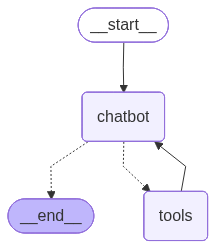

In [54]:
# 시각화
time_travel_graph

### 체크포인트 시퀀스 생성

여러 번 대화를 실행하여 상태 이력을 생성합니다. 각 실행마다 새로운 체크포인트가 생성되어 나중에 특정 시점으로 롤백할 수 있습니다.

아래 코드는 첫 번째 검색 대화를 실행합니다.

In [55]:
time_travel_config = RunnableConfig(configurable={"thread_id": "time-travel-1"})

# 첫 번째 대화
stream_graph(
    time_travel_graph,
    inputs={"messages": [HumanMessage(content="테디노트에 대해서 조사 좀 해주세요.")]},
    config=time_travel_config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "테디노트", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://wikidocs.net/profile/info/book/10226", "title": "테디노트 - 위키독스", "content": ":   블로그와 유튜브 \"테디노트\"를 운영하고 있으며, \"파이썬 딥러닝 텐서플로\"를 집필하였습니다. <랭체인LangChain 노트> - LangChain 한국어 튜토리얼🇰🇷. \\*\\*\"추천\"\\*\\* 한 번씩만 부탁 드리겠습니다🙏🙏 ✅ \\*\\*랭체인 한국어 튜토리얼 강의\\*\\* 패스트캠퍼스 - RAG ✅ \\*\\*랭체인 한국어 튜토리얼 코드저장소(GitHub)\\*\\* 📘🖥️ ✅ \\*\\*유튜브 \"테디노트\"\\*…. 수정: 2025년 4월 30일 8:06 오후. [한 권으로 끝내는 <판다스 노트>. 수정: 2024년 6월 24일 1:45 오후. 한 권으로 끝내는 <파이썬 노트>. '파이썬 노트' 강의는 처음 파이썬을 접하거나, 파이썬 공부를 시작했다가…. 수정: 2023년 6월 7일 3:41 오후. 한 권으로 끝내는 <머신러닝 노트>. 머신러닝은 최근 가장 주목받고 있는 인공지능 분야 가운데 하나입니다. 머신러닝은 데이터를 기반으로 다양한 통계적 알고리즘을 활용하여 컴퓨터가 스스로 학습할 수 있도록 프로그래밍 하는 것을 의미합니다. 수정: 2024년 2월 2일 2:45 오전. ## 들어가기 전에 이 책은 유튜브 '테디노트'의 2만 구독자의 설문을 기반으로, 랭체인 개념부터 실무를 위한 Advanced RAG가 궁금한 분들을 대상으로 만들었습니다. 수정: 2025년 3월

In [56]:
# 두 번째 대화
stream_graph(
    time_travel_graph,
    inputs={
        "messages": [HumanMessage(content="테디노트 온라인 강의 주소를 조사 해주세요.")]
    },
    config=time_travel_config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "테디노트 온라인 강의 주소 링크", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://linktr.ee/teddynote", "title": "linktr.ee/teddynote | Linktree", "content": "Jenn Leuke@jenneatsgoood\n\nDiscover more\n\n@keefe.physio@TestSubject001@kbscelularcenter@canevasmusica@donnabelle\\_hairmastery@525fx@Moniquecherise@tekoha.arq@ifeszt.we@stage082718@patrick\\_kinas@leanne11a@urbeaa@sabrinapimentel.arq@kaitlyn.n.wells@cartaodescontosaosebastiao@kalyanssk@jonasfill@FergusonZAP@OSIS\\_MPK.SKENDA@dkriukvgb@ciyona@overborstvoeding@AZDETAILED@iragobrr@siescebuddhi24@thehaircartel\\_@moncefbeg@culturadelgranobr@yramawidya.official@OtherSideSounds@blno3x3@cherishclay06@habitguys@nhandecacau@life\\_is\\_in\\_your\\_favor@sybilproductions@twinkletwinklelittlesleepover@atlantablackchambers@petalsandprosecco2024@starhumanfoundation@de

### 상태 이력 탐색

`get_state_history`로 전체 상태 이력을 조회하고 롤백할 체크포인트를 선택합니다. 이력은 최신순으로 반환되며, 각 체크포인트에는 해당 시점의 상태 정보가 포함됩니다.

아래 코드는 상태 이력을 조회하고 특정 조건(메시지 수가 6개)에 해당하는 체크포인트를 선택합니다.

In [57]:
# 전체 상태 히스토리 확인
print("상태 히스토리 (최신순):")
print("=" * 80)

# to_replay 변수 초기화
to_replay = None

for i, state in enumerate(time_travel_graph.get_state_history(time_travel_config)):
    print(f"\n[체크포인트 {i}]")
    print(f"  다음 노드: {state.next}")
    print(f"  체크포인트 ID: {state.config['configurable']['checkpoint_id']}")

    if len(state.values["messages"]) == 6 and to_replay is None:
        print("  이 상태로 되돌아갈 예정")
        display_message_tree(state.values["messages"][-1])
        to_replay = state


print("\n" + "=" * 80)

상태 히스토리 (최신순):

[체크포인트 0]
  다음 노드: ()
  체크포인트 ID: 1f1259d6-93aa-61c9-8010-741938d71355

[체크포인트 1]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f1259d5-d0c8-60ea-800f-e86b721c2934

[체크포인트 2]
  다음 노드: ('tools',)
  체크포인트 ID: 1f1259d5-a5dd-6fb5-800e-270c680df351

[체크포인트 3]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f1259d5-91ae-6547-800d-b38879fd52ef

[체크포인트 4]
  다음 노드: ('tools',)
  체크포인트 ID: 1f1259d5-7dbe-60f5-800c-ea539dac34ed

[체크포인트 5]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f1259d5-5fb6-6174-800b-dac2f66e7770

[체크포인트 6]
  다음 노드: ('tools',)
  체크포인트 ID: 1f1259d5-47a4-63db-800a-ed2178709f6e

[체크포인트 7]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f1259d5-2d40-6369-8009-8039d2281f91

[체크포인트 8]
  다음 노드: ('__start__',)
  체크포인트 ID: 1f1259d5-2d40-6368-8008-c179ade27dc9

[체크포인트 9]
  다음 노드: ()
  체크포인트 ID: 1f1259d5-2d18-6d63-8007-7e0e7f1b67e4

[체크포인트 10]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f1259d4-a4df-6cbf-8006-4a64869f0007

[체크포인트 11]
  다음 노드: ('tools',)
  체크포인트 ID: 1f1259d4-7c80-65b9-8005-7162a142979d
  이 상태로 되돌아갈 예정
    conte

### 체크포인트로 롤백

선택한 체크포인트의 상태를 확인합니다. 이 시점의 마지막 메시지 내용을 표시하여 어느 지점으로 돌아갈지 확인할 수 있습니다.

아래 코드는 선택한 체크포인트의 마지막 메시지를 표시합니다.

In [58]:
display_message_tree(to_replay.values["messages"][-1])

    content:
        index [0]
            id: "toolu_01MMA7HVJ2w3ViNm6QAnqoSh"
            caller: {"type": "direct"}
            input: {}
            name: "tavily_search"
            type: "tool_use"
            index: 0
            partial_json: "{"query": "teddylee777 블로그 테디노트", "search_depth": "advanced"}"
    additional_kwargs: {}
    response_metadata: {"model_name": "claude-sonnet-4-5-20250929", "model_provider": "anthropic", "stop_reason": "tool_use", "stop_sequence": None}
    type: "ai"
    name: None
    id: "lc_run--019d1389-b4f8-7621-97f9-0ea29be16981"
    tool_calls:
        index [0]
            name: "tavily_search"
            args: {"query": "teddylee777 블로그 테디노트", "search_depth": "advanced"}
            id: "toolu_01MMA7HVJ2w3ViNm6QAnqoSh"
            type: "tool_call"
    invalid_tool_calls:
    usage_metadata:
        input_tokens: 3881
        output_tokens: 86
        total_tokens: 3967
        input_token_details: {"cache_creation": 0, "cache_read": 0}


### 상태 수정

복원된 상태에서 도구 호출 파라미터를 수정합니다. `update_tool_call` 함수를 사용하면 기존 도구 호출의 인자를 변경할 수 있어, 다른 검색어로 재실행할 수 있습니다.

아래 코드는 Tavily 검색 도구의 쿼리를 수정합니다.

In [59]:
from langchain_teddynote.tools import update_tool_call

# 사용 예시:
updated_message = update_tool_call(
    to_replay.values["messages"][-1],
    tool_name="tavily_search",
    tool_args={"query": "테디노트 온라인 강의 site:naver.com", "search_depth": "basic"},
)

In [60]:
updated_message

AIMessage(content=[{'id': 'toolu_01MMA7HVJ2w3ViNm6QAnqoSh', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'tavily_search', 'type': 'tool_use', 'index': 0, 'partial_json': '{"query": "teddylee777 블로그 테디노트", "search_depth": "advanced"}'}], additional_kwargs={}, response_metadata={'model_name': 'claude-sonnet-4-5-20250929', 'model_provider': 'anthropic', 'stop_reason': 'tool_use', 'stop_sequence': None}, id='lc_run--019d1389-b4f8-7621-97f9-0ea29be16981', tool_calls=[{'name': 'tavily_search', 'args': {'query': '테디노트 온라인 강의 site:naver.com', 'search_depth': 'basic'}, 'id': 'toolu_01MMA7HVJ2w3ViNm6QAnqoSh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 3881, 'output_tokens': 86, 'total_tokens': 3967, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})

In [61]:
# 변경하기 전의 message
display_message_tree(to_replay.values["messages"][-1])

    content:
        index [0]
            id: "toolu_01MMA7HVJ2w3ViNm6QAnqoSh"
            caller: {"type": "direct"}
            input: {}
            name: "tavily_search"
            type: "tool_use"
            index: 0
            partial_json: "{"query": "teddylee777 블로그 테디노트", "search_depth": "advanced"}"
    additional_kwargs: {}
    response_metadata: {"model_name": "claude-sonnet-4-5-20250929", "model_provider": "anthropic", "stop_reason": "tool_use", "stop_sequence": None}
    type: "ai"
    name: None
    id: "lc_run--019d1389-b4f8-7621-97f9-0ea29be16981"
    tool_calls:
        index [0]
            name: "tavily_search"
            args: {"query": "teddylee777 블로그 테디노트", "search_depth": "advanced"}
            id: "toolu_01MMA7HVJ2w3ViNm6QAnqoSh"
            type: "tool_call"
    invalid_tool_calls:
    usage_metadata:
        input_tokens: 3881
        output_tokens: 86
        total_tokens: 3967
        input_token_details: {"cache_creation": 0, "cache_read": 0}


In [62]:
# 변경한 이후의 메시지 트리
display_message_tree(updated_message)

    content:
        index [0]
            id: "toolu_01MMA7HVJ2w3ViNm6QAnqoSh"
            caller: {"type": "direct"}
            input: {}
            name: "tavily_search"
            type: "tool_use"
            index: 0
            partial_json: "{"query": "teddylee777 블로그 테디노트", "search_depth": "advanced"}"
    additional_kwargs: {}
    response_metadata: {"model_name": "claude-sonnet-4-5-20250929", "model_provider": "anthropic", "stop_reason": "tool_use", "stop_sequence": None}
    type: "ai"
    name: None
    id: "lc_run--019d1389-b4f8-7621-97f9-0ea29be16981"
    tool_calls:
        index [0]
            name: "tavily_search"
            args: {"query": "테디노트 온라인 강의 site:naver.com", "search_depth": "basic"}
            id: "toolu_01MMA7HVJ2w3ViNm6QAnqoSh"
            type: "tool_call"
    invalid_tool_calls:
    usage_metadata:
        input_tokens: 3881
        output_tokens: 86
        total_tokens: 3967
        input_token_details: {"cache_creation": 0, "cache_read": 0}


In [63]:
# 변경된 메시지를 update_state 로 업데이트
updated_state = time_travel_graph.update_state(
    values={"messages": [updated_message]}, config=to_replay.config
)

### 수정 상태 재실행

업데이트된 상태로 그래프를 재실행하여 결과를 확인합니다. `update_state` 메서드로 상태를 수정하면 해당 시점부터 새로운 경로로 실행이 계속됩니다.

아래 코드는 수정된 검색 쿼리로 그래프를 재실행합니다.

In [64]:
# 업데이트된 메시지를 스트리밍 합니다.
stream_graph(time_travel_graph, inputs=None, config=updated_state)


🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "테디노트 온라인 강의", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.naver.com/queerfish/140097090291?viewType=pc", "title": "테디토익 방학특강 안내 : 네이버 블로그", "content": "테디토익 입문반은 매 방학마다 조기 마감되는 인기강좌입니다. · 5년연속 인천 최다수강생 동원 인기강좌” · “이보다 더 쉬울 순 없다” 초보자가 가장 쉽게", "score": 0.99932814, "raw_content": null}], "response_time": 0.83, "request_id": "b4d8d261-f43e-418d-bd32-4e4b95713ad0"}
🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "테디노트 파이썬 랭체인 머신러닝", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://wikidocs.net/profile/info/book/10226", "title": "테디노트 - 위키독스", "content": "한 권으로 끝내는 <파이썬 노트>\n\n저자: 테디노트, Min\n\n파이썬은 배우기 쉬우면서도 확장성이 뛰어난 프로그래밍 언어입니다. 때문에 파이썬은 초보자와 숙련자 모두에게 매우 유용한 언어이며, 중요한 것은 시간이 지날수록 더욱 유망한 프로그래밍 언어가 될 것이라는 점입니다. '파이썬 노트' 강의는 처음 파이썬을